# Курсовая работа: NER в финансовой области




In [ ]:
!pip install -q transformers datasets seqeval accelerate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import json
import requests
from datasets import Dataset, DatasetDict

def load_json_from_url(url):
    response = requests.get(url)
    response.raise_for_status()
    data = [json.loads(line) for line in response.iter_lines(decode_unicode=True) if line]
    return Dataset.from_list(data)

dataset_dict = DatasetDict({
    "train": load_json_from_url("https://huggingface.co/datasets/tner/fin/raw/main/dataset/train.json"),
    "validation": load_json_from_url("https://huggingface.co/datasets/tner/fin/raw/main/dataset/valid.json"),
    "test": load_json_from_url("https://huggingface.co/datasets/tner/fin/raw/main/dataset/test.json"),
})

print(dataset_dict)

DatasetDict({
    train: Dataset({
        features: ['tags', 'tokens'],
        num_rows: 1018
    })
    validation: Dataset({
        features: ['tags', 'tokens'],
        num_rows: 150
    })
    test: Dataset({
        features: ['tags', 'tokens'],
        num_rows: 305
    })
})


Map:   0%|          | 0/1018 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

Map:   0%|          | 0/305 [00:00<?, ? examples/s]

=== Statistical dataset ===
train: 1018 samples
validation: 150 samples
test: 305 samples

=== Label distribution on the train ===
O: 35255 (96.35%)
B-PER: 650 (1.78%)
I-ORG: 178 (0.49%)
B-LOC: 172 (0.47%)
I-PER: 158 (0.43%)
B-MISC: 134 (0.37%)
B-ORG: 36 (0.10%)
I-LOC: 7 (0.02%)


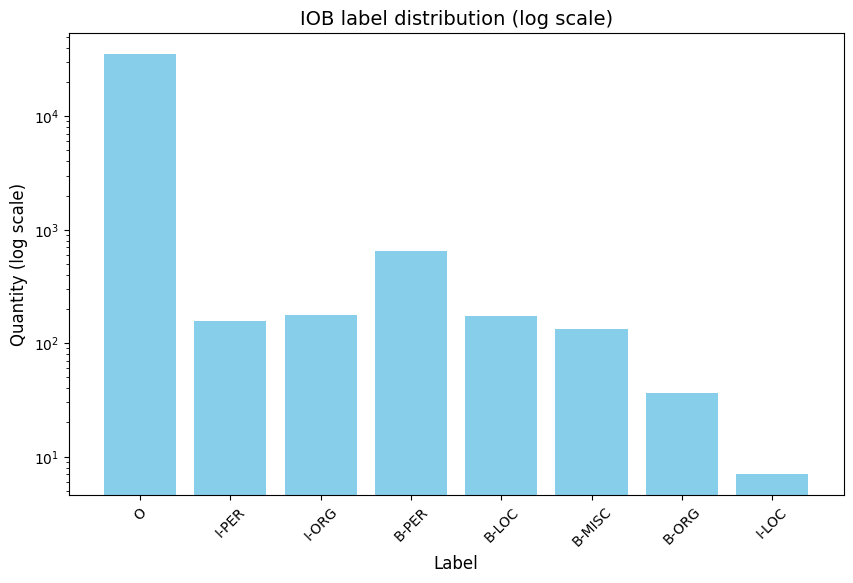


=== Statistics on sentence length (number of tokens) ===
Train: mean=35.9, std=41.9, min=1, max=413
Validation: mean=29.5, std=32.2, min=3, max=212
Test: mean=43.4, std=63.7, min=1, max=641


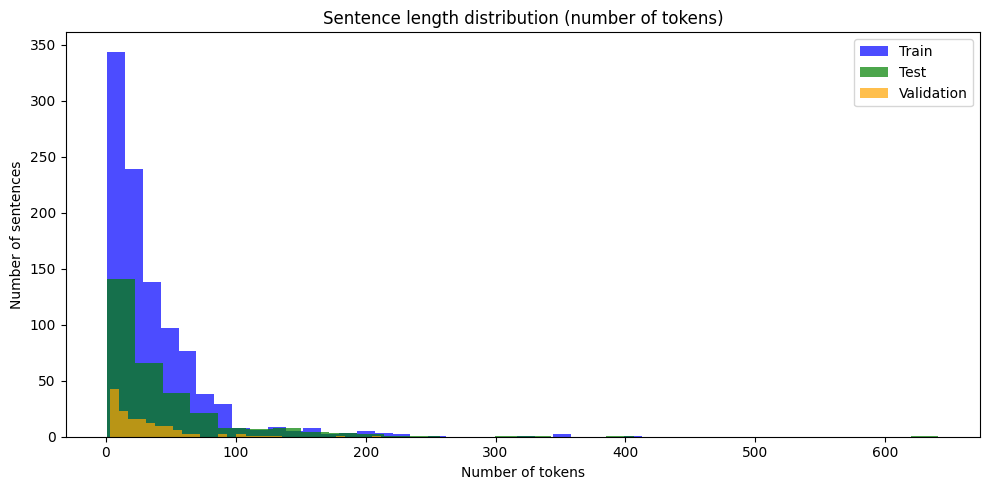


=== Example samples from the training set ===

--- Sample 1 ---
Tokens: ['(', 'l', ')', '"', 'Tranche', 'A', 'Shares', '"', 'has', 'the', 'meaning', 'as', 'defined', 'in', 'the', 'Subscription', 'Agreement', '.']
NER tags: ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']
Detail: [('(', 'O'), ('l', 'O'), (')', 'O'), ('"', 'O'), ('Tranche', 'O'), ('A', 'O'), ('Shares', 'O'), ('"', 'O'), ('has', 'O'), ('the', 'O')] ...

--- Sample 2 ---
Tokens: ['(', 'm', ')', '"', 'Tranche', 'B', 'Cash', 'Payment', '"', 'has', 'the', 'meaning', 'as', 'defined', 'in', 'the', 'Subscription', 'Agreement', '.']
NER tags: ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']
Detail: [('(', 'O'), ('m', 'O'), (')', 'O'), ('"', 'O'), ('Tranche', 'O'), ('B', 'O'), ('Cash', 'O'), ('Payment', 'O'), ('"', 'O'), ('has', 'O')] ...

--- Sample 3 ---
Tokens: ['(', 'n', ')', '"', 'USD', '"', 'means', 'US', 'dollars', ',', 'the', 'lawful'

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pandas as pd
import numpy as np

if "ner_tags" not in dataset_dict["train"].column_names:
    if "ner_tags_str" in dataset_dict["train"].column_names:
        for split in dataset_dict.keys():
            dataset_dict[split] = dataset_dict[split].rename_column("ner_tags_str", "ner_tags")
    elif "tags" in dataset_dict["train"].column_names:
        tag_names = ['O', 'B-PER', 'I-PER', 'B-LOC', 'I-LOC', 'B-ORG', 'I-ORG', 'B-MISC', 'I-MISC']
        def add_ner_tags(example):
            example["ner_tags"] = [tag_names[t] for t in example["tags"]]
            return example
        dataset_dict = dataset_dict.map(add_ner_tags, remove_columns=["tags"])
    else:
        raise ValueError("No column found that can generate 'ner_tags' (requires 'tags' or 'ner_tags_str')")

print("=== Statistical dataset ===")
for split in dataset_dict.keys():
    print(f"{split}: {len(dataset_dict[split])} samples")

# Label distribution (on the training set)
all_tags = []
for tags in dataset_dict["train"]["ner_tags"]:
    all_tags.extend(tags)
tag_counts = Counter(all_tags)
print("\n=== Label distribution on the train ===")
for tag, count in sorted(tag_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"{tag}: {count} ({count/len(all_tags)*100:.2f}%)")

# Label distribution chart (log scale)
plt.figure(figsize=(10, 6))
plt.bar(tag_counts.keys(), tag_counts.values(), color='skyblue')
plt.yscale('log')
plt.title('IOB label distribution (log scale)', fontsize=14)
plt.xlabel('Label', fontsize=12)
plt.ylabel('Quantity (log scale)', fontsize=12)
plt.xticks(rotation=45)
plt.show()

# Sentence length distribution (number of tokens)
train_lengths = [len(tokens) for tokens in dataset_dict["train"]["tokens"]]
val_lengths = [len(tokens) for tokens in dataset_dict["validation"]["tokens"]]
test_lengths = [len(tokens) for tokens in dataset_dict["test"]["tokens"]]

print("\n=== Statistics on sentence length (number of tokens) ===")
print(f"Train: mean={np.mean(train_lengths):.1f}, std={np.std(train_lengths):.1f}, min={np.min(train_lengths)}, max={np.max(train_lengths)}")
print(f"Validation: mean={np.mean(val_lengths):.1f}, std={np.std(val_lengths):.1f}, min={np.min(val_lengths)}, max={np.max(val_lengths)}")
print(f"Test: mean={np.mean(test_lengths):.1f}, std={np.std(test_lengths):.1f}, min={np.min(test_lengths)}, max={np.max(test_lengths)}")

# Sentence length histogram
plt.figure(figsize=(10, 5))
plt.hist(train_lengths, bins=30, alpha=0.7, label='Train', color='blue')
plt.hist(test_lengths, bins=30, alpha=0.7, label='Test', color='green')
plt.hist(val_lengths, bins=30, alpha=0.7, label='Validation', color='orange')
plt.title("Sentence length distribution (number of tokens)")
plt.xlabel("Number of tokens")
plt.ylabel("Number of sentences")
plt.legend()
plt.tight_layout()
plt.show()

print("\n=== Example samples from the training set ===")
for i in range(min(5, len(dataset_dict["train"]))):
    sample = dataset_dict["train"][i]
    tokens = sample["tokens"]
    ner_tags = sample["ner_tags"]
    print(f"\n--- Sample {i+1} ---")
    print("Tokens:", tokens)
    print("NER tags:", ner_tags)
    word_tag_pairs = list(zip(tokens, ner_tags))
    print("Detail:", word_tag_pairs[:10], "..." if len(tokens) > 10 else "")

In [ ]:
train_cols = dataset_dict["train"].column_names
print("Train columns:", train_cols)

if "ner_tags" in train_cols:
    print("Dataset already has 'ner_tags' column (string IOB). No conversion needed.")
    pass
elif "tags" in train_cols:
    print("Converting 'tags' IDs to IOB strings...")
    tags_feature = dataset_dict["train"].features["tags"]
    if hasattr(tags_feature, 'feature') and hasattr(tags_feature.feature, 'names'):
        tag_names = tags_feature.feature.names
    elif hasattr(tags_feature, 'names'):
        tag_names = tags_feature.names
    else:
        tag_names = ['O', 'B-PER', 'I-PER', 'B-LOC', 'I-LOC', 'B-ORG', 'I-ORG', 'B-MISC', 'I-MISC']
    print("Tag names:", tag_names)

    def convert_tags_to_names(example):
        example["ner_tags"] = [tag_names[tag_id] for tag_id in example["tags"]]
        return example

    dataset_dict = dataset_dict.map(convert_tags_to_names, remove_columns=["tags"])
    print("Converted. New columns:", dataset_dict["train"].column_names)
else:
    raise ValueError("Dataset has neither 'tags' nor 'ner_tags' column. Please check the dataset structure.")

Train columns: ['tokens', 'ner_tags']
Dataset already has 'ner_tags' column (string IOB). No conversion needed.


In [ ]:
unique_labels = set()
for tags in dataset_dict["train"]["ner_tags"]:
    unique_labels.update(tags)
label_list = sorted(unique_labels)
if "O" in label_list:
    label_list.remove("O")
    label_list.insert(0, "O")
print("Number of labels:", len(label_list))
print("Label list:", label_list)

label_to_id = {l: i for i, l in enumerate(label_list)}
id_to_label = {i: l for l, i in label_to_id.items()}
num_labels = len(label_list)

Number of labels: 8
Label list: ['O', 'B-LOC', 'B-MISC', 'B-ORG', 'B-PER', 'I-LOC', 'I-ORG', 'I-PER']


In [ ]:
from transformers import AutoTokenizer, AutoModelForTokenClassification

model_name = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForTokenClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    id2label=id_to_label,
    label2id=label_to_id,
    ignore_mismatched_sizes=True
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |                                                                                     
-----------------------------+------------+-------------------------------------------------------------------------------------
bert.pooler.dense.weight     | UNEXPECTED |                                                                                     
bert.pooler.dense.bias       | UNEXPECTED |                                                                                     
bert.embeddings.position_ids | UNEXPECTED |                                                                                     
classifier.weight            | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([3, 768]) vs model:torch.Size([8, 768])
classifier.bias              | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([3]) vs model:torch.Size([8])          

Notes:
- UNEXPECTED	:can be ignore

In [ ]:
def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(
        examples["tokens"],
        truncation=True,
        is_split_into_words=True,
        max_length=512,
        padding=False
    )
    labels = []
    for i, ner_tags in enumerate(examples["ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                label_ids.append(label_to_id[ner_tags[word_idx]])
            else:
                label_ids.append(-100)
            previous_word_idx = word_idx
        labels.append(label_ids)
    tokenized_inputs["labels"] = labels
    return tokenized_inputs

tokenized_datasets = dataset_dict.map(tokenize_and_align_labels, batched=True)
tokenized_datasets = tokenized_datasets.remove_columns(["tokens", "ner_tags"])
print(tokenized_datasets["train"].column_names)  # ['input_ids', 'attention_mask', 'labels']

Map:   0%|          | 0/1018 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

Map:   0%|          | 0/305 [00:00<?, ? examples/s]

['input_ids', 'token_type_ids', 'attention_mask', 'labels']


In [ ]:
import numpy as np
from seqeval.metrics import f1_score, precision_score, recall_score

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)
    true_predictions = [
        [id_to_label[p] for (p, l) in zip(pred, lab) if l != -100]
        for pred, lab in zip(predictions, labels)
    ]
    true_labels = [
        [id_to_label[l] for (p, l) in zip(pred, lab) if l != -100]
        for pred, lab in zip(predictions, labels)
    ]
    return {
        "precision": precision_score(true_labels, true_predictions),
        "recall": recall_score(true_labels, true_predictions),
        "f1": f1_score(true_labels, true_predictions)
    }

In [ ]:
from transformers import TrainingArguments, Trainer, DataCollatorForTokenClassification

variants = [
    {"name": "H1", "lr": 2e-5, "batch": 16, "epochs": 3},
    {"name": "H2", "lr": 5e-5, "batch": 16, "epochs": 5},
    {"name": "H3", "lr": 3e-5, "batch": 8,  "epochs": 4},
]

results = {}
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

for variant in variants:
    print(f"\n=== Training {variant['name']} (lr={variant['lr']}, batch={variant['batch']}, epochs={variant['epochs']}) ===")
    model = AutoModelForTokenClassification.from_pretrained(
        model_name,
        num_labels=num_labels,
        id2label=id_to_label,
        label2id=label_to_id,
        ignore_mismatched_sizes=True
    )
    training_args = TrainingArguments(
        output_dir=f"./tner_fin_{variant['name']}",
        learning_rate=variant['lr'],
        per_device_train_batch_size=variant['batch'],
        per_device_eval_batch_size=variant['batch'],
        num_train_epochs=variant['epochs'],
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        logging_steps=10,
    )
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
    trainer.train()
    eval_result = trainer.evaluate(tokenized_datasets["test"])
    results[variant['name']] = {
        "precision": eval_result["eval_precision"],
        "recall": eval_result["eval_recall"],
        "f1": eval_result["eval_f1"]
    }
    trainer.save_model(f"./tner_fin_{variant['name']}_final")
    tokenizer.save_pretrained(f"./tner_fin_{variant['name']}_final")
    print(f"Finished {variant['name']}, F1: {eval_result['eval_f1']:.4f}")


=== Training H1 (lr=2e-05, batch=16, epochs=3) ===


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |                                                                                     
-----------------------------+------------+-------------------------------------------------------------------------------------
bert.pooler.dense.weight     | UNEXPECTED |                                                                                     
bert.pooler.dense.bias       | UNEXPECTED |                                                                                     
bert.embeddings.position_ids | UNEXPECTED |                                                                                     
classifier.weight            | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([3, 768]) vs model:torch.Size([8, 768])
classifier.bias              | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([3]) vs model:torch.Size([8])          

Notes:
- UNEXPECTED	:can be ignore

Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,0.043343,0.044803,0.958084,0.833333,0.891365
2,0.055472,0.032543,0.919786,0.895833,0.907652
3,0.032872,0.029906,0.925926,0.911458,0.918635


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Finished H3, F1: 0.7958


In [ ]:
import pandas as pd
df = pd.DataFrame(results).T
print("=== tner/fin Results (1018 train) ===")
print(df)

=== tner/fin Results (1018 train) ===
    precision    recall        f1
H1   0.782609  0.655340  0.713342
H2   0.776978  0.786408  0.781665
H3   0.766292  0.827670  0.795799


In [ ]:
from transformers import Trainer, DataCollatorForTokenClassification
import numpy as np
from seqeval.metrics import classification_report

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)
trainer = Trainer(model=model, data_collator=data_collator)

predictions, labels, _ = trainer.predict(tokenized_datasets["test"])
predictions = np.argmax(predictions, axis=2)

true_labels = [
    [id_to_label[l] for l in label if l != -100]
    for label in labels
]
pred_labels = [
    [id_to_label[p] for p, l in zip(pred, label) if l != -100]
    for pred, label in zip(predictions, labels)
]

print(classification_report(true_labels, pred_labels, digits=4))

              precision    recall  f1-score   support

         LOC     0.5758    0.6129    0.5938        62
        MISC     0.5970    0.6780    0.6349        59
         ORG     0.5745    0.6429    0.6067        42
         PER     0.8906    0.9478    0.9183       249

   micro avg     0.7663    0.8277    0.7958       412
   macro avg     0.6595    0.7204    0.6884       412
weighted avg     0.7689    0.8277    0.7971       412



In [ ]:
import random

# Extract the index of samples with incorrect predictions.
error_indices = []
for i, (true, pred) in enumerate(zip(true_labels, pred_labels)):
    if true != pred:
        error_indices.append(i)

print(f"Total error samples: {len(error_indices)}/{len(true_labels)}")

samples_to_show = random.sample(error_indices, min(3, len(error_indices)))

for idx in samples_to_show:
    tokens = tokenizer.convert_ids_to_tokens(tokenized_datasets["test"][idx]["input_ids"])
    # Get a list of tokens that are not -100.
    true_tags = true_labels[idx]
    pred_tags = pred_labels[idx]

    print(f"\nSample {idx}:")
    print("Tokens:", tokens)
    print("True:", true_tags)
    print("Pred:", pred_tags)
    # Find the difference
    for j, (t, p) in enumerate(zip(true_tags, pred_tags)):
        if t != p:
            print(f"  Mismatch at token {j}: True={t}, Pred={p}")
    print("-" * 50)

Total error samples: 35/305

Sample 63:
Tokens: ['[CLS]', '(', 'd', ')', 'successive', 'assignments', 'of', 'borrow', '##er', "'", 's', 'rights', 'under', 'this', 'loan', 'agreement', 'shall', 'remain', 'subject', 'to', 'this', 'article', '10', '.', '1', 'provided', 'that', 'si', '##lic', '##ium', 'de', 'provence', 's', '.', 'a', '.', 's', '.', '[SEP]']
True: ['O', 'O', 'O', 'O', 'O', 'O', 'B-PER', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-LOC', 'B-MISC', 'B-MISC', 'O', 'O', 'O', 'O', 'O', 'O']
Pred: ['O', 'O', 'O', 'O', 'O', 'O', 'B-PER', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-LOC', 'B-MISC', 'I-PER', 'O', 'O', 'O', 'O', 'O', 'O']
  Mismatch at token 27: True=B-MISC, Pred=I-PER
--------------------------------------------------

Sample 14:
Tokens: ['[CLS]', 'se', '##verance', '8', '14', '.', '[SEP]']
True: ['O', 'O', 'O', 'O']
Pred: ['O', 'I-ORG', 'O', 'O']
  Mismatch at token 1: T

In [ ]:
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForTokenClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    id2label=id_to_label,
    label2id=label_to_id,
    ignore_mismatched_sizes=True
)

def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(
        examples["tokens"],
        truncation=True,
        is_split_into_words=True,
        max_length=512,
        padding=False
    )
    labels = []
    for i, ner_tags in enumerate(examples["ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                # Convert string labels (e.g., 'B-PER') into IDs.
                label_ids.append(label_to_id[ner_tags[word_idx]])
            else:
                label_ids.append(-100)
            previous_word_idx = word_idx
        labels.append(label_ids)
    tokenized_inputs["labels"] = labels
    return tokenized_inputs

# Tokenize dataset
tokenized_datasets = dataset_dict.map(tokenize_and_align_labels, batched=True)
tokenized_datasets = tokenized_datasets.remove_columns(["tokens", "ner_tags"])

variants = [
    {"name": "H1", "lr": 2e-5, "batch": 16, "epochs": 3},
    {"name": "H2", "lr": 5e-5, "batch": 16, "epochs": 5},
    {"name": "H3", "lr": 3e-5, "batch": 8,  "epochs": 4},
]

results_distilbert = {}
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

for variant in variants:
    print(f"\n=== Training DistilBERT {variant['name']} ===")
    model = AutoModelForTokenClassification.from_pretrained(
        model_name,
        num_labels=num_labels,
        id2label=id_to_label,
        label2id=label_to_id,
        ignore_mismatched_sizes=True
    )
    training_args = TrainingArguments(
        output_dir=f"./distilbert_{variant['name']}",
        learning_rate=variant['lr'],
        per_device_train_batch_size=variant['batch'],
        per_device_eval_batch_size=variant['batch'],
        num_train_epochs=variant['epochs'],
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        logging_steps=10,
    )
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
    trainer.train()
    eval_result = trainer.evaluate(tokenized_datasets["test"])
    results_distilbert[variant['name']] = {
        "precision": eval_result["eval_precision"],
        "recall": eval_result["eval_recall"],
        "f1": eval_result["eval_f1"]
    }
    print(f"Finished {variant['name']}, F1: {eval_result['eval_f1']:.4f}")

import pandas as pd
df_distilbert = pd.DataFrame(results_distilbert).T
print("=== DistilBERT Results ===")
print(df_distilbert)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Finished H3, F1: 0.7757
=== DistilBERT Results ===
    precision    recall        f1
H1   0.822878  0.541262  0.653001
H2   0.807388  0.742718  0.773704
H3   0.747748  0.805825  0.775701


In [ ]:
from seqeval.metrics import classification_report

predictions, labels, _ = trainer.predict(tokenized_datasets["test"])
predictions = np.argmax(predictions, axis=2)

true_labels = [[id_to_label[l] for l in label if l != -100] for label in labels]
pred_labels = [[id_to_label[p] for p, l in zip(pred, label) if l != -100] for pred, label in zip(predictions, labels)]

print(classification_report(true_labels, pred_labels, digits=4))

              precision    recall  f1-score   support

         LOC     0.6032    0.6129    0.6080        62
        MISC     0.5652    0.6610    0.6094        59
         ORG     0.4706    0.3810    0.4211        42
         PER     0.8597    0.9598    0.9070       249

   micro avg     0.7477    0.8058    0.7757       412
   macro avg     0.6247    0.6537    0.6364       412
weighted avg     0.7393    0.8058    0.7699       412



In [ ]:
# Error samples cho DistilBERT
error_indices = [i for i, (true, pred) in enumerate(zip(true_labels, pred_labels)) if true != pred]
print(f"Total error samples: {len(error_indices)}/{len(true_labels)}")

import random
samples_to_show = random.sample(error_indices, min(3, len(error_indices)))

for idx in samples_to_show:
    tokens = tokenizer.convert_ids_to_tokens(tokenized_datasets["test"][idx]["input_ids"])
    true_tags = true_labels[idx]
    pred_tags = pred_labels[idx]
    print(f"\nSample {idx}:")
    print("Tokens:", tokens)
    print("True:", true_tags)
    print("Pred:", pred_tags)
    for j, (t, p) in enumerate(zip(true_tags, pred_tags)):
        if t != p:
            print(f"  Mismatch at token {j}: True={t}, Pred={p}")
    print("-" * 50)

Total error samples: 37/305

Sample 63:
Tokens: ['[CLS]', '(', 'd', ')', 'successive', 'assignments', 'of', 'borrow', '##er', "'", 's', 'rights', 'under', 'this', 'loan', 'agreement', 'shall', 'remain', 'subject', 'to', 'this', 'article', '10', '.', '1', 'provided', 'that', 'si', '##lic', '##ium', 'de', 'provence', 's', '.', 'a', '.', 's', '.', '[SEP]']
True: ['O', 'O', 'O', 'O', 'O', 'O', 'B-PER', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-LOC', 'B-MISC', 'B-MISC', 'O', 'O', 'O', 'O', 'O', 'O']
Pred: ['O', 'O', 'O', 'O', 'O', 'O', 'B-PER', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']
  Mismatch at token 25: True=B-LOC, Pred=O
  Mismatch at token 26: True=B-MISC, Pred=O
  Mismatch at token 27: True=B-MISC, Pred=O
--------------------------------------------------

Sample 1:
Tokens: ['[CLS]', 'subordinate', '##d', 'loan', 'agreement', 'herbert', 'sm

In [ ]:
!pip install -q sklearn-crfsuite seqeval

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.3 MB/s eta 0:00:00


In [ ]:
if isinstance(dataset_dict["train"][0]["ner_tags"][0], int):
    tag_names = ['O', 'B-PER', 'I-PER', 'B-LOC', 'I-LOC', 'B-ORG', 'I-ORG', 'B-MISC', 'I-MISC']
    def to_iob(example):
        example["ner_tags_iob"] = [tag_names[t] for t in example["ner_tags"]]
        return example
    dataset_dict = dataset_dict.map(to_iob, remove_columns=[])
    label_column = "ner_tags_iob"
else:
    label_column = "ner_tags"

print("Using label column:", label_column)

Using label column: ner_tags


In [ ]:
import sklearn_crfsuite
from seqeval.metrics import classification_report

def word2features(sent, i):
    word = sent[i][0]
    features = {
        'word.lower()': word.lower(),
        'word[-3:]': word[-3:],
        'word[-2:]': word[-2:],
        'word.isupper()': word.isupper(),
        'word.istitle()': word.istitle(),
        'word.isdigit()': word.isdigit(),
        'bias': 1.0,
    }
    if i > 0:
        word1 = sent[i-1][0]
        features.update({
            '-1:word.lower()': word1.lower(),
            '-1:word.istitle()': word1.istitle(),
            '-1:word.isupper()': word1.isupper(),
        })
    else:
        features['BOS'] = True
    if i < len(sent)-1:
        word1 = sent[i+1][0]
        features.update({
            '+1:word.lower()': word1.lower(),
            '+1:word.istitle()': word1.istitle(),
            '+1:word.isupper()': word1.isupper(),
        })
    else:
        features['EOS'] = True
    return features

def sent2features(sent):
    return [word2features(sent, i) for i in range(len(sent))]

def sent2labels(sent):
    return [label for (token, label) in sent]

# Create a list of sentences (each sentence is a list of (token, label))
train_sentences = [list(zip(toks, labs)) for toks, labs in zip(dataset_dict["train"]["tokens"], dataset_dict["train"][label_column])]
val_sentences = [list(zip(toks, labs)) for toks, labs in zip(dataset_dict["validation"]["tokens"], dataset_dict["validation"][label_column])]
test_sentences = [list(zip(toks, labs)) for toks, labs in zip(dataset_dict["test"]["tokens"], dataset_dict["test"][label_column])]

X_train = [sent2features(s) for s in train_sentences]
y_train = [sent2labels(s) for s in train_sentences]
X_val = [sent2features(s) for s in val_sentences]
y_val = [sent2labels(s) for s in val_sentences]
X_test = [sent2features(s) for s in test_sentences]
y_test = [sent2labels(s) for s in test_sentences]

In [ ]:
import sklearn_crfsuite
from seqeval.metrics import precision_score, recall_score, f1_score
import pandas as pd

variants_crf = [
    {"name": "H1", "c1": 0.1, "c2": 0.1, "max_iter": 100},
    {"name": "H2", "c1": 0.01, "c2": 0.01, "max_iter": 100},
    {"name": "H3", "c1": 1.0, "c2": 1.0, "max_iter": 100},
]

results_crf = {}

for variant in variants_crf:
    print(f"\n=== Training CRF {variant['name']} (c1={variant['c1']}, c2={variant['c2']}, max_iter={variant['max_iter']}) ===")
    crf = sklearn_crfsuite.CRF(
        algorithm='lbfgs',
        c1=variant['c1'],
        c2=variant['c2'],
        max_iterations=variant['max_iter'],
        all_possible_transitions=True,
        verbose=False
    )
    crf.fit(X_train, y_train)
    y_pred = crf.predict(X_test)

    p = precision_score(y_test, y_pred)
    r = recall_score(y_test, y_pred)
    f = f1_score(y_test, y_pred)

    results_crf[variant['name']] = {
        "precision": p,
        "recall": r,
        "f1": f
    }
    print(f"Finished {variant['name']}, Precision={p:.4f}, Recall={r:.4f}, F1={f:.4f}")

df_crf = pd.DataFrame(results_crf).T
print("\n=== CRF Results ===")
print(df_crf.round(6))


=== Training CRF H1 (c1=0.1, c2=0.1, max_iter=100) ===
Finished H1, Precision=0.8763, Recall=0.5962, F1=0.7096

=== Training CRF H2 (c1=0.01, c2=0.01, max_iter=100) ===
Finished H2, Precision=0.8732, Recall=0.5962, F1=0.7086

=== Training CRF H3 (c1=1.0, c2=1.0, max_iter=100) ===
Finished H3, Precision=0.9414, Recall=0.5409, F1=0.6870

=== CRF Results ===
    precision    recall        f1
H1   0.876325  0.596154  0.709585
H2   0.873239  0.596154  0.708571
H3   0.941423  0.540865  0.687023


In [ ]:
import numpy as np
from seqeval.metrics import classification_report
import random

y_pred = crf.predict(X_test)


print("=== CRF Classification Report ===")
print(classification_report(y_test, y_pred, digits=4))

# Find the false prediction patterns (perfect matches)
error_indices = []
for i, (true, pred) in enumerate(zip(y_test, y_pred)):
    if true != pred:
        error_indices.append(i)

print(f"Total error samples: {len(error_indices)}/{len(y_test)}")


samples_to_show = random.sample(error_indices, min(3, len(error_indices)))

test_tokens = dataset_dict["test"]["tokens"]   # list of token lists

for idx in samples_to_show:
    tokens = test_tokens[idx]
    true_tags = y_test[idx]
    pred_tags = y_pred[idx]
    print(f"\nSample {idx}:")
    print("Tokens:", tokens)
    print("True:", true_tags)
    print("Pred:", pred_tags)
    for j, (t, p) in enumerate(zip(true_tags, pred_tags)):
        if t != p:
            print(f"  Mismatch at token {j}: True={t}, Pred={p}")
    print("-" * 50)

=== CRF Classification Report ===
              precision    recall  f1-score   support

         LOC     0.6957    0.2581    0.3765        62
        MISC     0.1667    0.0169    0.0308        59
         ORG     0.8750    0.1667    0.2800        42
         PER     0.9950    0.7945    0.8835       253

   micro avg     0.9414    0.5409    0.6870       416
   macro avg     0.6831    0.3090    0.3927       416
weighted avg     0.8208    0.5409    0.6261       416

Total error samples: 36/305

Sample 99:
Tokens: ['The', 'arbitration', 'shall', 'be', 'conducted', 'in', 'English', 'and', 'the', 'seat', 'shall', 'be', 'Paris', '.']
True: ['O', 'O', 'O', 'O', 'O', 'O', 'I-LOC', 'O', 'O', 'O', 'O', 'O', 'I-PER', 'O']
Pred: ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']
  Mismatch at token 6: True=I-LOC, Pred=O
  Mismatch at token 12: True=I-PER, Pred=O
--------------------------------------------------

Sample 95:
Tokens: ['16', '.', '2', 'The', 'language', 'of', 'thi

=== Compare the three models (best value according to F1) ===

     Model  Precision   Recall  F1-score
   FinBERT   0.766292 0.827670  0.795799
DistilBERT   0.747748 0.805825  0.775701
       CRF   0.876325 0.596154  0.709585


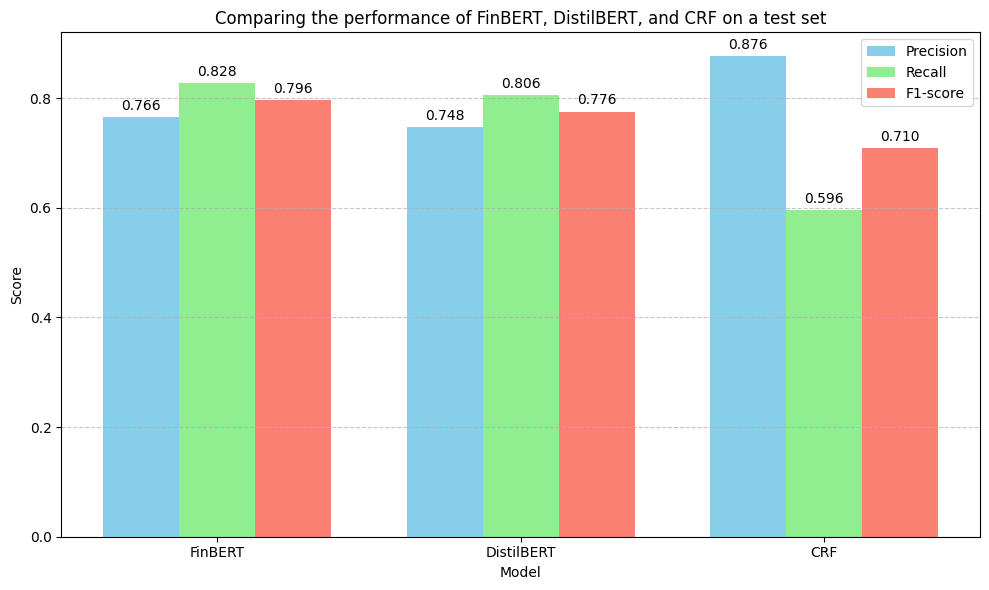

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

best_finbert = max(results.values(), key=lambda x: x['f1'])
best_distilbert = max(results_distilbert.values(), key=lambda x: x['f1'])
best_crf = max(results_crf.values(), key=lambda x: x['f1'])

comparison = pd.DataFrame({
    'Model': ['FinBERT', 'DistilBERT', 'CRF'],
    'Precision': [best_finbert['precision'], best_distilbert['precision'], best_crf['precision']],
    'Recall':    [best_finbert['recall'],    best_distilbert['recall'],    best_crf['recall']],
    'F1-score':  [best_finbert['f1'],        best_distilbert['f1'],        best_crf['f1']]
})

print("=== Compare the three models (best value according to F1) ===\n")
print(comparison.to_string(index=False))


x = np.arange(len(comparison['Model']))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, comparison['Precision'], width, label='Precision', color='skyblue')
rects2 = ax.bar(x, comparison['Recall'], width, label='Recall', color='lightgreen')
rects3 = ax.bar(x + width, comparison['F1-score'], width, label='F1-score', color='salmon')


ax.bar_label(rects1, fmt='%.3f', padding=3)
ax.bar_label(rects2, fmt='%.3f', padding=3)
ax.bar_label(rects3, fmt='%.3f', padding=3)

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Comparing the performance of FinBERT, DistilBERT, and CRF on a test set')
ax.set_xticks(x)
ax.set_xticklabels(comparison['Model'])
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

=== Details of all variations ===

     Model Variant  Precision   Recall       F1
       CRF      H1   0.876325 0.596154 0.709585
       CRF      H2   0.873239 0.596154 0.708571
       CRF      H3   0.941423 0.540865 0.687023
DistilBERT      H1   0.822878 0.541262 0.653001
DistilBERT      H2   0.807388 0.742718 0.773704
DistilBERT      H3   0.747748 0.805825 0.775701
   FinBERT      H1   0.782609 0.655340 0.713342
   FinBERT      H2   0.776978 0.786408 0.781665
   FinBERT      H3   0.766292 0.827670 0.795799


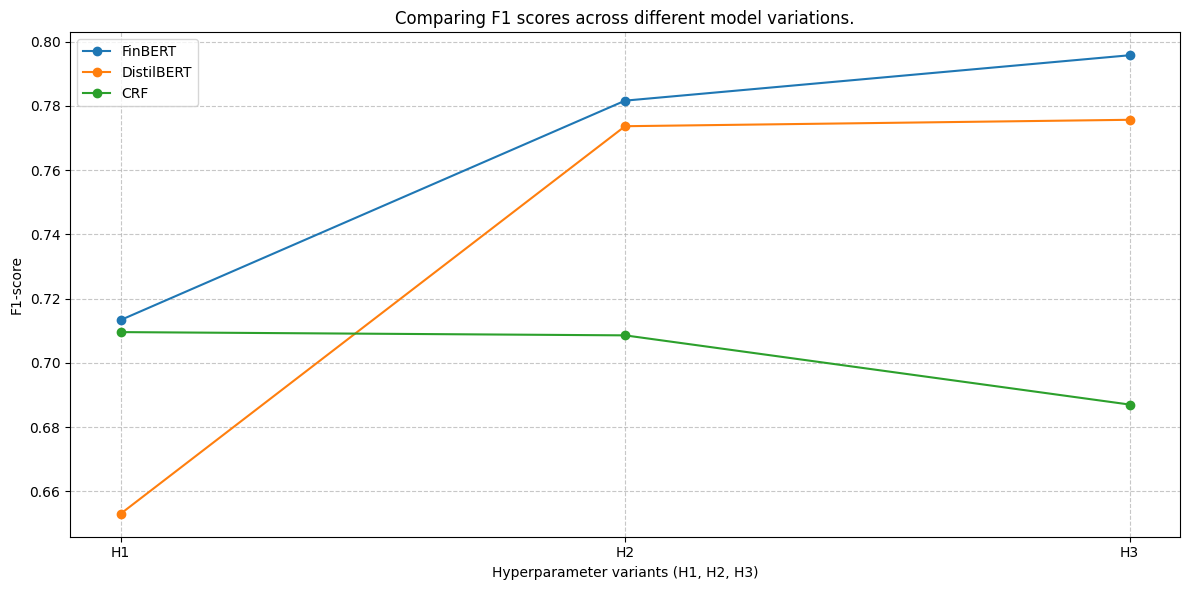

In [ ]:
all_results = []
for model_name, res_dict in [('FinBERT', results), ('DistilBERT', results_distilbert), ('CRF', results_crf)]:
    for variant, scores in res_dict.items():
        all_results.append({
            'Model': model_name,
            'Variant': variant,
            'Precision': scores['precision'],
            'Recall': scores['recall'],
            'F1': scores['f1']
        })

df_all = pd.DataFrame(all_results)
print("=== Details of all variations ===\n")
print(df_all.sort_values(['Model', 'Variant']).to_string(index=False))

plt.figure(figsize=(12, 6))
for model in df_all['Model'].unique():
    subset = df_all[df_all['Model'] == model]
    plt.plot(subset['Variant'], subset['F1'], marker='o', label=model)

plt.xlabel('Hyperparameter variants (H1, H2, H3)')
plt.ylabel('F1-score')
plt.title('Comparing F1 scores across different model variations.')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()